In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./data/processed/comptages_propre.csv', sep = ',')

df.head()

,libelle,q,k,etat_trafic,libelle_nd_amont,libelle_nd_aval,etat_barre,Dates_Paris
0,Bd_Macdonald,94.0,NaN,Inconnu,Bd Macdonald-Allee des Cardinoux,Bd_Macdonald - Jaques Duchesne,Ouvert,2026-09-01 01:00:00+02:00
1,Bd_Macdonald,94.0,0.52500,Fluide,Bd_Macdonald - Jaques Duchesne,Bd_Macdonald - Lounes Matoub,Ouvert,2026-09-01 01:00:00+02:00
2,Bd_Macdonald,NaN,0.51833,Fluide,Bd_Macdonald - Chana Orloff,Bd_Macdonald - Lounes Matoub,Ouvert,2026-09-01 01:00:00+02:00
3,Bd_Macdonald,48.0,NaN,Inconnu,Bd_Macdonald - Lounes Matoub,Bd Macdonald - Rue E. 019,Ouvert,2026-09-01 01:00:00+02:00
4,Bd_Macdonald,NaN,NaN,Inconnu,Bd Macdonald - Rue E. 019,Bd_Macdonald - Chana Orloff,Invalide,2026-09-01 01:00:00+02:00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200744 entries, 0 to 200743
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   libelle           200744 non-null  object 
 1   q                 112709 non-null  float64
 2   k                 89777 non-null   float64
 3   etat_trafic       200744 non-null  object 
 4   libelle_nd_amont  200744 non-null  object 
 5   libelle_nd_aval   200744 non-null  object 
 6   etat_barre        200744 non-null  object 
 7   Dates_Paris       200744 non-null  object 
dtypes: float64(2), object(6)
memory usage: 12.3+ MB


In [4]:
# Convertir proprement la colonne 'Dates_Paris' en datetime
df['Dates_Paris'] = pd.to_datetime(df['Dates_Paris'], utc=True).dt.tz_convert('Europe/Paris')

**1. Variables temporelles en heure de Paris**

In [5]:
# Colonne pour l'heure 
df['heure'] = df['Dates_Paris'].dt.hour

# Colonne pour le jour de la semaine 
df['jour_semaine'] = df['Dates_Paris'].dt.dayofweek

# Colonne pour le week-end 
df['weekend'] = df['Dates_Paris'].dt.dayofweek >= 5

# Colonne pour le mois 
df['mois'] = df['Dates_Paris'].dt.month

df[['heure','jour_semaine','weekend','mois']].head()

,heure,jour_semaine,weekend,mois
0,1,1,False,9
1,1,1,False,9
2,1,1,False,9
3,1,1,False,9
4,1,1,False,9


**2. Encodage : Montrez que l'ordre existe (ou non) avant de choisir ordinal ou one-hot**

In [6]:
df['etat_barre'].unique()

array(['Ouvert', 'Invalide', 'Barré'], dtype=object)

Il n'y a pas de hiérarchie entre les états 'Ouvert', 'Invalide' et 'Barré'. Il n'y a donc pas d'ordre, il faut utiliser un encodage One-Hot

In [7]:
# Encodage One-Hot de la colonne 
df = pd.get_dummies(df, columns=['etat_barre'], prefix='barre')

In [8]:
df['etat_trafic'].unique()

array(['Inconnu', 'Fluide', 'Pré-saturé', 'Saturé', 'Bloqué'],
      dtype=object)

`etat_trafic` a un ordre, il faut donc utiliser l'encodage ordinal

In [9]:
# Définition de l'ordre logique 
ordre_trafic = {'Fluide': 0, 'Pré-saturé': 1, 'Saturé': 2, 'Bloqué': 3}

# Encodage ordinal
df['etat_trafic'] = df['etat_trafic'].map(ordre_trafic).astype("float")

In [10]:
df.head()

,libelle,q,k,etat_trafic,libelle_nd_amont,libelle_nd_aval,Dates_Paris,heure,jour_semaine,weekend,mois,barre_Barré,barre_Invalide,barre_Ouvert
0,Bd_Macdonald,94.0,NaN,NaN,Bd Macdonald-Allee des Cardinoux,Bd_Macdonald - Jaques Duchesne,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True
1,Bd_Macdonald,94.0,0.52500,0.0,Bd_Macdonald - Jaques Duchesne,Bd_Macdonald - Lounes Matoub,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True
2,Bd_Macdonald,NaN,0.51833,0.0,Bd_Macdonald - Chana Orloff,Bd_Macdonald - Lounes Matoub,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True
3,Bd_Macdonald,48.0,NaN,NaN,Bd_Macdonald - Lounes Matoub,Bd Macdonald - Rue E. 019,2026-09-01 01:00:00+02:00,1,1,False,9,False,False,True
4,Bd_Macdonald,NaN,NaN,NaN,Bd Macdonald - Rue E. 019,Bd_Macdonald - Chana Orloff,2026-09-01 01:00:00+02:00,1,1,False,9,False,True,False


**3. Valeurs aberrantes : comparez l'IQR à ce qui est physiquement impossible sur **vos** capteurs. Décidez : supprimer, plafonner, garder, et pourquoi.**

In [11]:
def hors_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return (s < q1 - 1.5 * (q3 - q1)) | (s > q3 + 1.5 * (q3 - q1))

df["aberrant_iqr"] = df.groupby("libelle")["q"].transform(hors_iqr)

print(f"Valeurs signalées par l'IQR: {df['aberrant_iqr'].sum()}")

Valeurs signalées par l'IQR: 3054


Le résultat nous montre qu'il y a 3054 valeurs aberrantes 

In [12]:
df.nlargest(10, "q")[["libelle", "Dates_Paris", "q", "k", "etat_trafic"]]

,libelle,Dates_Paris,q,k,etat_trafic
3959,Bd_Macdonald,2026-08-28 11:00:00+02:00,5036.95,NaN,NaN
3966,Bd_Macdonald,2026-08-28 11:00:00+02:00,5036.95,6.55945,0.0
137734,Bd_Macdonald,2026-04-29 07:00:00+02:00,5028.95,NaN,NaN
137761,Bd_Macdonald,2026-04-29 07:00:00+02:00,5028.95,NaN,NaN
66981,Bd_Macdonald,2026-07-02 09:00:00+02:00,889.00,NaN,NaN
67000,Bd_Macdonald,2026-07-02 09:00:00+02:00,889.00,13.94834,0.0
67002,Bd_Macdonald,2026-07-02 09:00:00+02:00,889.00,NaN,NaN
181605,Bd_Macdonald,2026-03-18 09:00:00+01:00,870.00,NaN,NaN
42300,Bd_Macdonald,2026-07-24 18:00:00+02:00,863.00,NaN,NaN
65874,Bd_Macdonald,2026-07-03 09:00:00+02:00,856.00,NaN,NaN


Les débits dépassant 5 000 véh/h avec une occupation très faible,un état de trafic fluide, est physiquement impossibles. La présence de la décimale ".95" sur un comptage de véhicules, qui doit être un nombre entier, est la signature d'une erreur de capteur. Contrairement aux pics statistiques de l'IQR qu'il faut conserver, nous devons supprimer ces données.

In [13]:
import numpy as np

# Identification des valeurs physiquement impossibles (supérieures à 5000)
impossible = df["q"] > 5000

# Remplacement de ces débits erronés par des valeurs manquantes (NaN)
df.loc[impossible, "q"] = np.nan

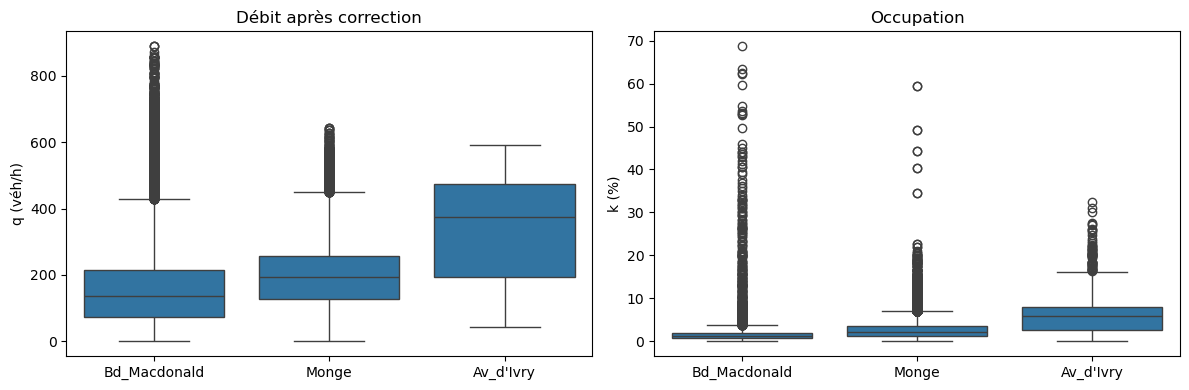

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Création de la figure avec 2 graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

# 1er graphique (q)
sns.boxplot(data=df, x="libelle", y="q", ax=axes[0])
axes[0].set(title="Débit après correction", xlabel="", ylabel="q (véh/h)")

# 2ème graphique (k)
sns.boxplot(data=df, x="libelle", y="k", ax=axes[1])
axes[1].set(title="Occupation", xlabel="", ylabel="k (%)")

# Ajustement de l'espacement et affichage
plt.tight_layout()
plt.show()

**4. Statistiques par tronçon + 3 phrases d'interprétation**

In [15]:
stats = (df.groupby(["libelle"], observed=True)[["q", "k"]]
         .agg(["mean", "median", "std"]).round(1))
stats.head(10)

q                  k            
               mean median    std mean median  std
libelle                                           
Av_d'Ivry     335.7  374.5  155.8  5.9    5.9  3.9
Bd_Macdonald  164.9  137.0  123.2  1.7    1.2  2.4
Monge         199.1  194.0   98.4  2.7    2.1  2.1

In [16]:
q_unique = df.dropna(subset=["q"]).drop_duplicates(["q", "libelle"])

par_axe = pd.concat({
    "q (séries uniques)": q_unique.groupby("libelle", observed=True)["q"].agg(["mean", "median", "std", "max"]),
    "k (tous les tronçons)": df.groupby("libelle", observed=True)["k"].agg(["mean", "median", "std", "max"]),
}, axis=1).round(1)

par_axe

q (séries uniques)                      k (tous les tronçons)  \
                           mean median    std    max                  mean   
libelle                                                                      
Av_d'Ivry                 324.0  358.0  160.5  592.0                   5.9   
Bd_Macdonald              363.2  351.5  222.0  889.0                   1.7   
Monge                     288.8  287.0  164.5  643.0                   2.7   

                                
             median  std   max  
libelle                         
Av_d'Ivry       5.9  3.9  32.4  
Bd_Macdonald    1.2  2.4  68.7  
Monge           2.1  2.1  59.5

Sur le Bd_Macdonald et la rue Monge, la moyenne de l'occupation dépasse la médiane. Sur l'Av d'Ivry en revanche, moyenne et médiane sont égales, signifiant un trafic régulier.

In [17]:
# Heures les plus congestionnées par axe, jours ouvrés
ouvres = df[~df["weekend"]]
pointe = (ouvres.groupby(["libelle", "heure"], observed=True)["k"].median()
          .groupby(level=0, observed=True).nlargest(3).droplevel(0))
pointe.round(1)

libelle       heure
Av_d'Ivry     13       8.7
              9        8.7
              16       8.6
Bd_Macdonald  18       2.2
              19       2.1
              17       2.0
Monge         10       4.1
              11       3.9
              9        3.9
Name: k, dtype: float64

Le profil de congestion varie fortement en fonction des axes en semaine. Le Boulevard Macdonald subit une pointe le soir entre 17h et 19h. La rue Monge se charge le matin de 9h à 11h. Tandis que l'Avenue d'Ivry a un trafic dense et réparti sur la journée (9h, 13h et 16h).

In [18]:
# Moments extrêmes
idx_max = df.groupby("libelle", observed=True)["k"].idxmax()
df.loc[idx_max, ["libelle", "Dates_Paris", "q", "k", "etat_trafic"]]

,libelle,Dates_Paris,q,k,etat_trafic
40338,Av_d'Ivry,2026-07-26 13:00:00+02:00,NaN,32.39611,2.0
108622,Bd_Macdonald,2026-05-25 16:00:00+02:00,NaN,68.71667,3.0
76456,Monge,2026-06-23 19:00:00+02:00,304.0,59.46056,3.0


Ces pics de tension révèlent des saturations critiques, atteignant près de 69 % d'occupation sur le Boulevard Macdonald et 60 % sur Monge en état de trafic bloqué.

In [19]:
df.to_csv("data/processed/comptages_features.csv", index=False)